1️⃣ Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import joblib

2️⃣ Load Dataset

In [3]:
df = pd.read_csv("kidney_disease_dataset.csv")

df.head()

,Age,Creatinine_Level,BUN,Diabetes,Hypertension,GFR,Urine_Output,CKD_Status,Dialysis_Needed
0,71,0.30,40.9,0,1,46.8,1622.0,1,0
1,34,1.79,17.1,0,0,43.8,1428.0,1,0
2,80,2.67,15.0,0,1,78.2,1015.0,1,0
3,40,0.97,31.1,0,1,92.8,1276.0,1,0
4,43,2.05,22.8,1,1,62.2,1154.0,0,0


3️⃣ Basic Information

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2304, 9)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               2304 non-null   int64  
 1   Creatinine_Level  2304 non-null   float64
 2   BUN               2304 non-null   float64
 3   Diabetes          2304 non-null   int64  
 4   Hypertension      2304 non-null   int64  
 5   GFR               2304 non-null   float64
 6   Urine_Output      2304 non-null   float64
 7   CKD_Status        2304 non-null   int64  
 8   Dialysis_Needed   2304 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 162.1 KB


In [6]:
print(df.columns)

Index(['Age', 'Creatinine_Level', 'BUN', 'Diabetes', 'Hypertension', 'GFR',
       'Urine_Output', 'CKD_Status', 'Dialysis_Needed'],
      dtype='str')


In [7]:
df.dtypes

Age                   int64
Creatinine_Level    float64
BUN                 float64
Diabetes              int64
Hypertension          int64
GFR                 float64
Urine_Output        float64
CKD_Status            int64
Dialysis_Needed       int64
dtype: object

4️⃣ Statistical Summary

In [8]:
df.describe()

,Age,Creatinine_Level,BUN,Diabetes,Hypertension,GFR,Urine_Output,CKD_Status,Dialysis_Needed
count,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000
mean,54.159288,1.305638,18.813672,0.406684,0.498264,68.953863,1309.189670,0.508681,0.013455
std,20.513729,0.789594,10.508358,0.491322,0.500106,24.660191,491.951914,0.500033,0.115237
min,20.000000,0.300000,5.000000,0.000000,0.000000,5.000000,100.000000,0.000000,0.000000
25%,36.000000,0.620000,9.975000,0.000000,0.000000,51.300000,967.750000,0.000000,0.000000
50%,54.000000,1.240000,18.200000,0.000000,0.000000,69.150000,1295.500000,1.000000,0.000000
75%,72.000000,1.842500,26.000000,1.000000,1.000000,86.300000,1633.500000,1.000000,0.000000
max,90.000000,4.130000,61.900000,1.000000,1.000000,120.000000,2899.000000,1.000000,1.000000


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2304.0,54.159288,20.513729,20.0,36.000,54.00,72.0000,90.00
Creatinine_Level,2304.0,1.305638,0.789594,0.3,0.620,1.24,1.8425,4.13
BUN,2304.0,18.813672,10.508358,5.0,9.975,18.20,26.0000,61.90
Diabetes,2304.0,0.406684,0.491322,0.0,0.000,0.00,1.0000,1.00
Hypertension,2304.0,0.498264,0.500106,0.0,0.000,0.00,1.0000,1.00
GFR,2304.0,68.953863,24.660191,5.0,51.300,69.15,86.3000,120.00
Urine_Output,2304.0,1309.189670,491.951914,100.0,967.750,1295.50,1633.5000,2899.00
CKD_Status,2304.0,0.508681,0.500033,0.0,0.000,1.00,1.0000,1.00
Dialysis_Needed,2304.0,0.013455,0.115237,0.0,0.000,0.00,0.0000,1.00


5️⃣ Check Missing Values

In [10]:
df.isnull().sum()

Age                 0
Creatinine_Level    0
BUN                 0
Diabetes            0
Hypertension        0
GFR                 0
Urine_Output        0
CKD_Status          0
Dialysis_Needed     0
dtype: int64

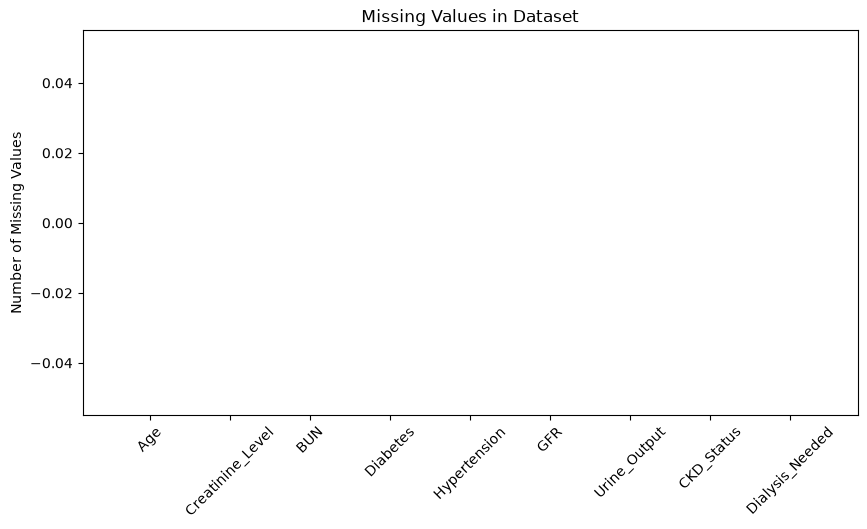

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(df.columns, df.isnull().sum())

plt.xticks(rotation=45)

plt.title("Missing Values in Dataset")

plt.ylabel("Number of Missing Values")

plt.show()

6️⃣ Check Duplicate Rows

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
df = df.drop_duplicates()

In [14]:
print(df.shape)

(2304, 9)


7️⃣ Check Target Distribution

In [15]:
df["CKD_Status"].value_counts()

CKD_Status
1    1172
0    1132
Name: count, dtype: int64

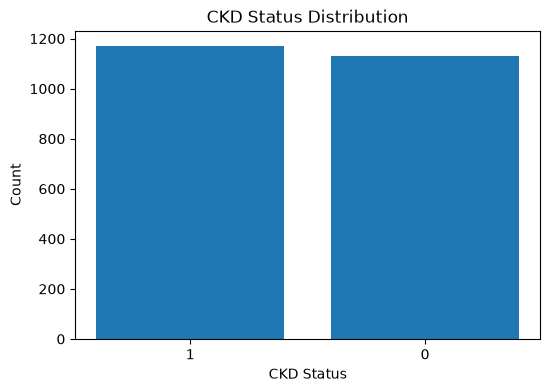

In [16]:
counts = df["CKD_Status"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(counts.index.astype(str), counts.values)

plt.title("CKD Status Distribution")

plt.xlabel("CKD Status")

plt.ylabel("Count")

plt.show()

In [17]:
df["CKD_Status"].value_counts(normalize=True) * 100

CKD_Status
1    50.868056
0    49.131944
Name: proportion, dtype: float64

8️⃣ Feature Distribution

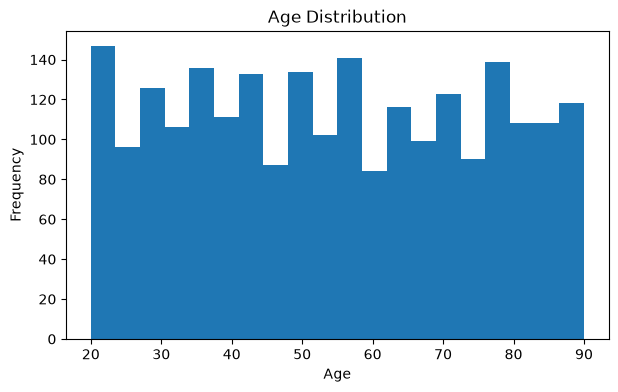

In [18]:
plt.figure(figsize=(7, 4))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

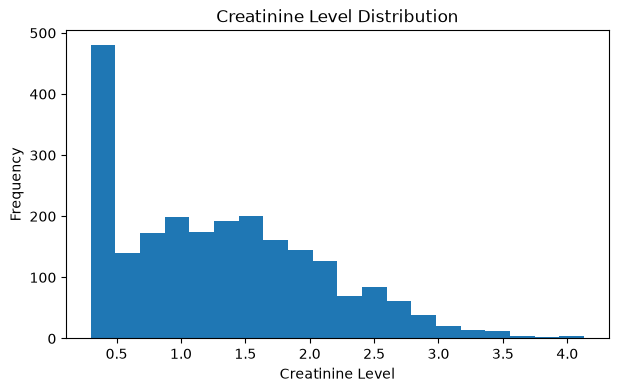

In [19]:
plt.figure(figsize=(7, 4))

plt.hist(df["Creatinine_Level"], bins=20)

plt.title("Creatinine Level Distribution")

plt.xlabel("Creatinine Level")

plt.ylabel("Frequency")

plt.show()

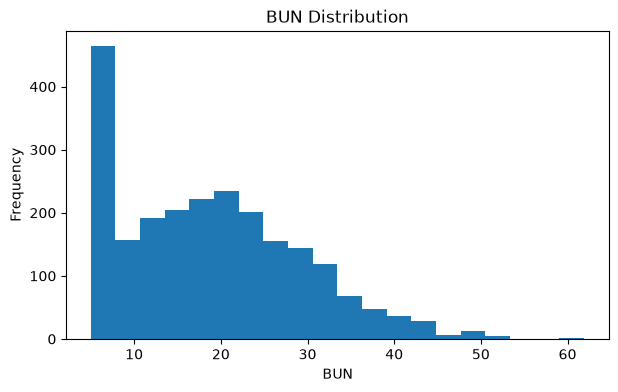

In [20]:
plt.figure(figsize=(7, 4))

plt.hist(df["BUN"], bins=20)

plt.title("BUN Distribution")

plt.xlabel("BUN")

plt.ylabel("Frequency")

plt.show()

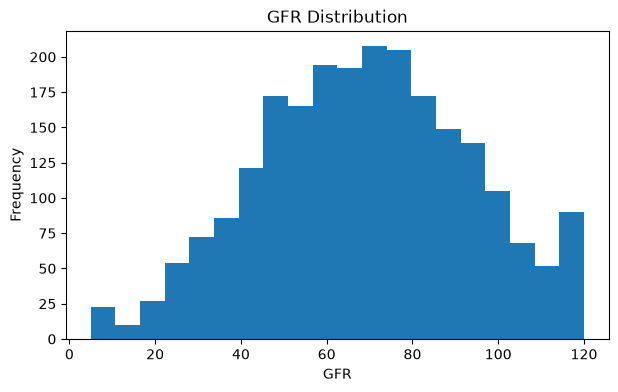

In [21]:
plt.figure(figsize=(7, 4))

plt.hist(df["GFR"], bins=20)

plt.title("GFR Distribution")

plt.xlabel("GFR")

plt.ylabel("Frequency")

plt.show()

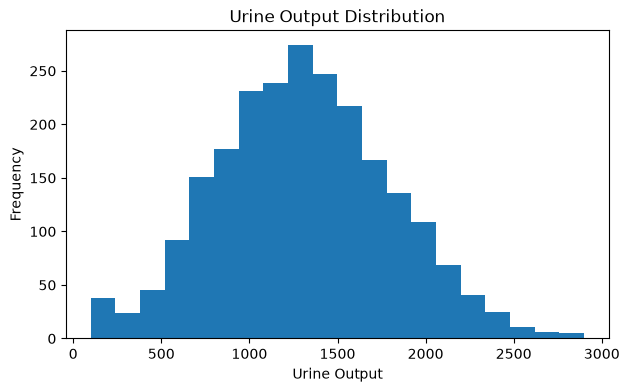

In [22]:
plt.figure(figsize=(7, 4))

plt.hist(df["Urine_Output"], bins=20)

plt.title("Urine Output Distribution")

plt.xlabel("Urine Output")

plt.ylabel("Frequency")

plt.show()

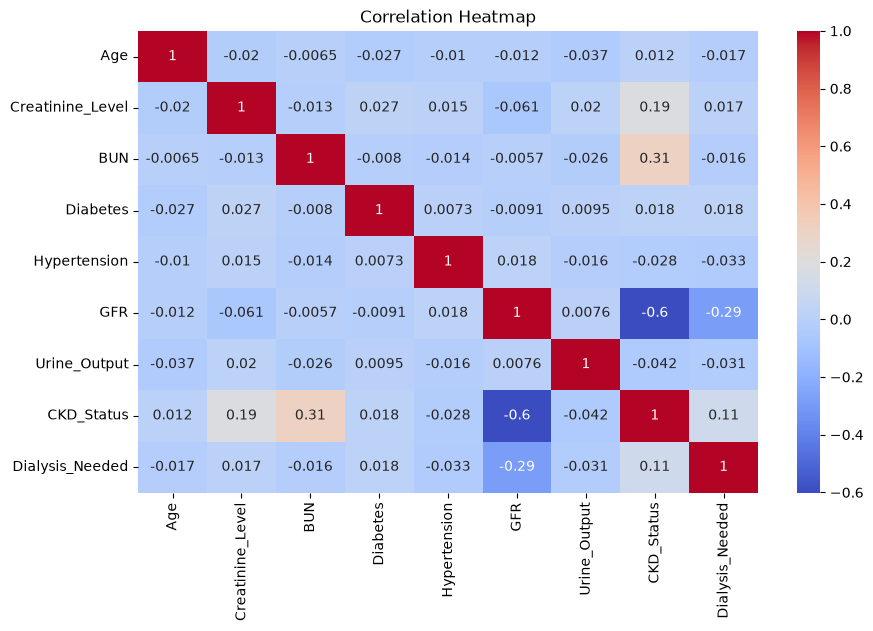

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()



In [ ]:

X = df.drop(columns=["CKD_Status", "Dialysis_Needed"])

y = df["CKD_Status"]
print(X.columns)

print(y.name)

Index(['Age', 'Creatinine_Level', 'BUN', 'Diabetes', 'Hypertension', 'GFR',
       'Urine_Output'],
      dtype='str')
CKD_Status


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1843, 7)
X_test shape: (461, 7)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)




In [29]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.8351409978308026


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)


In [31]:

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 1.0


In [32]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)



In [33]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.9566160520607375


In [34]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_svm
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.835141
1,Random Forest,1.000000
2,SVM,0.956616


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

Accuracy: 0.9566160520607375
Precision: 0.9574468085106383
Recall: 0.9574468085106383
F1 Score: 0.9574468085106383


In [37]:
import joblib

joblib.dump(svm_model, "kidney_model.pkl")
joblib.dump(scaler, "kidney_scaler.pkl")
joblib.dump(X.columns.tolist(), "kidney_columns.pkl")

['kidney_columns.pkl']